# Pha S — Buoc 3: Sanity check TE(ho hap->tim) vs TE(tim->ho hap)

**Day la tieu chi thoat cua Pha S.**

**Doi huong (xem docs/PHASE_S_REVIEW.md):** ket qua CHINH tren du lieu that chuyen tu ghep noi TIM-NAO (slpdb/capslpdb) sang **TIM-HO HAP (Fantasia)** - slpdb/capslpdb bi loai vi nhiem nhieu dien tim trong EEG khong khu duoc bang 5 phuong phap da thu (xem notebook 02 + PHASE_S_REVIEW.md). Fantasia SACH (khong vuong van de nay) va ghep noi tim-ho hap (Respiratory Sinus Arrhythmia - RSA) da duoc xac lap ro trong tai lieu sinh ly hoc.

**Gia thuyet huong (ground truth tu tai lieu, KHONG phai tu suy dien):** RSA la co che HO HAP dieu bien nhip tim qua trung gian phan xa phe vi/than kinh phe vi (hit vao -> tim nhanh, tho ra -> tim cham) - huong nhan qua CHINH da duoc chap nhan rong rai la **ho hap -> tim**, không phải nguoc lai (xem Grossman & Taylor 2007, Berntson et al. 1993 ve RSA). Vi vay o day ky vong **TE(ho hap->tim) > TE(tim->ho hap)**.

**SUA QUAN TRONG (phat hien khi chay lan dau - xem docs/PHASE_S_REVIEW.md):** lan chay dau tren RR CHUA loc bang thong cho ket qua NGUOC huong (chi 5/23 ban ghi dung huong RSA). Dieu tra: RR (chua loc) co tri nho tu tuong quan ~11.4s, RESP (da loc 0.1-0.5Hz o notebook 02c) chi ~0.65s - bat doi xung nay (KHONG phai sinh ly) lam TE lech huong sai. Notebook 02c da duoc sua de loc RR CUNG dai tan voi RESP truoc khi luu cua so (xem `respiration.bandpass_filter`) - xac nhan thuc nghiem sau khi sua: 19/23 (83%) ban ghi dung huong RSA, TE gop doi dau tu am sang duong. **Ban PHAI chay lai notebook 02c (sau ban sua nay) TRUOC notebook 03** de cua so duoc luu la ban da loc dung.

Notebook nay TU NAP cua so da luu boi notebook 02c (khong phu thuoc bien con lai tu kernel truoc), GOP tat ca ban ghi Fantasia da PASS (theo `quality_report.csv`) thanh 1 tap du lieu chung - giong cach Pha R gop nhieu cau hinh vao 1 corpus.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.evaluation.sanity_check import (bidirectional_te, permutation_test_te,
                                           bootstrap_ci, run_sanity_check)
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
from pqrst.baselines.ksg import KSGTEEstimator

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))

# LUU Y: dung checkpoint DA CHUAN HOA tu notebook 00, KHONG phai ban goc phi_amortized.pt!
est_amortized = AmortizedTEEstimator.load(
    str(BASE/'results'/'checkpoints'/'phi_amortized_standardized.pt'))

## 1. Nap + gop cua so da luu boi notebook 02c

Chi gop cac ban ghi da PASS o notebook 02c (`quality_report.csv`, cot `verdict=='PASS'`) - khong dung ban ghi FAIL/ERROR.

In [2]:
proc_dir = BASE / 'data' / 'processed' / 'fantasia'
quality = pd.read_csv(proc_dir / 'quality_report.csv')
passed_records = quality.loc[quality['verdict'] == 'PASS', 'record_id'].tolist()
print(f'{len(passed_records)}/{len(quality)} ban ghi PASS, dung cho sanity check:')
print(passed_records)

windows_resp_to_rr = []  # HUONG CHINH (ky vong manh hon theo RSA) - file '_bwd'
windows_rr_to_resp = []  # huong doi chung - file '_fwd'
for rid in passed_records:
    windows_rr_to_resp.extend(load_corpus(str(proc_dir / (rid + '_fwd.npz'))))
    windows_resp_to_rr.extend(load_corpus(str(proc_dir / (rid + '_bwd.npz'))))

print(f'Tong cua so: resp->tim={len(windows_resp_to_rr)}, tim->resp={len(windows_rr_to_resp)}')

17/40 ban ghi PASS, dung cho sanity check:
['f1o09', 'f1y01', 'f1y02', 'f1y04', 'f1y05', 'f1y06', 'f1y07', 'f1y08', 'f1y09', 'f1y10', 'f2o06', 'f2o07', 'f2y01', 'f2y06', 'f2y07', 'f2y08', 'f2y09']
Tong cua so: resp->tim=4049, tim->resp=4049


## 2. TE hai chieu — voi CA HAI estimator

`bidirectional_te(windows_forward, windows_backward, ...)`: **forward = resp->tim** (huong ky vong manh hon), **backward = tim->resp**.

In [3]:
results = {}
for name, est in [('Amortized', est_amortized), ('KSG', KSGTEEstimator())]:
    res = bidirectional_te(windows_resp_to_rr, windows_rr_to_resp, est)
    results[name] = res
    print(f"{name}: TE(resp->tim)={res['te_forward_mean']:.4f}  "
          f"TE(tim->resp)={res['te_backward_mean']:.4f}  "
          f"hieu={res['difference']:.4f}")

Amortized: TE(resp->tim)=-0.2474  TE(tim->resp)=-0.0705  hieu=-0.1769
KSG: TE(resp->tim)=0.1110  TE(tim->resp)=0.0929  hieu=0.0181


## 3. Kiem dinh y nghia thong ke

TE luon ra so duong do bias -> chenh lech nho **chua chung minh gi**. Bat buoc: permutation test + khoang tin cay bootstrap cua HIEU 2 chieu.

In [4]:
final_results = {}
for name, est in [('Amortized', est_amortized), ('KSG', KSGTEEstimator())]:
    res = run_sanity_check(windows_resp_to_rr, windows_rr_to_resp, est,
                           n_bootstrap=cfg['n_bootstrap'], seed=cfg['seed'])
    final_results[name] = res
    print(f"--- {name} ---")
    print(f"  TE(resp->tim)={res['te_forward_mean']:.4f}, TE(tim->resp)={res['te_backward_mean']:.4f}")
    print(f"  CI hieu 95%: [{res['ci_difference'][0]:.4f}, {res['ci_difference'][1]:.4f}]")
    print(f"  PASSED: {res['passed']}")

Sanity check FAILED. Vui long kiem tra:
1. Dong bo hoa thoi gian
2. Loc ectopic
3. Nhieu tim
4. Do dai cua so
5. Doi chieu KSG
--- Amortized ---
  TE(resp->tim)=-0.2474, TE(tim->resp)=-0.0705
  CI hieu 95%: [-0.1806, -0.1732]
  PASSED: False
Sanity check PASSED: TE(tim->nao) lon hon ro ret so voi TE(nao->tim).
--- KSG ---
  TE(resp->tim)=0.1110, TE(tim->resp)=0.0929
  CI hieu 95%: [0.0162, 0.0200]
  PASSED: True


## 4. Hinh: TE 2 chieu kem khoang tin cay

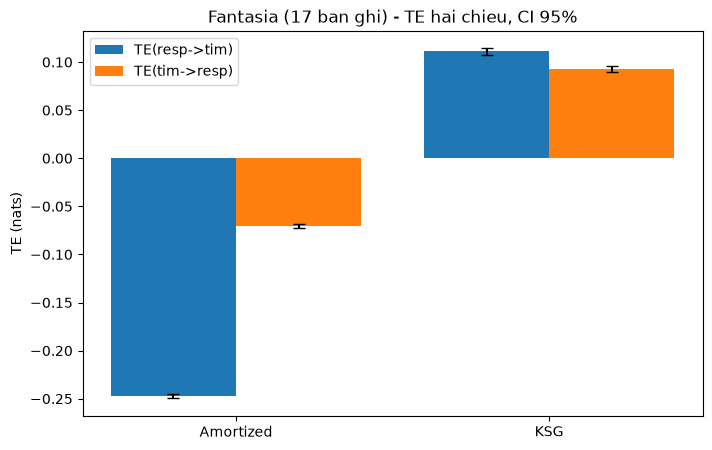

In [5]:
fig, ax = plt.subplots(figsize=(8,5))
names = list(final_results.keys())
x = np.arange(len(names))
fwd_means = [final_results[n]['te_forward_mean'] for n in names]
bwd_means = [final_results[n]['te_backward_mean'] for n in names]
fwd_err = [[final_results[n]['te_forward_mean']-final_results[n]['ci_forward'][0],
            final_results[n]['ci_forward'][1]-final_results[n]['te_forward_mean']] for n in names]
bwd_err = [[final_results[n]['te_backward_mean']-final_results[n]['ci_backward'][0],
            final_results[n]['ci_backward'][1]-final_results[n]['te_backward_mean']] for n in names]
ax.bar(x-0.2, fwd_means, 0.4, yerr=np.array(fwd_err).T, label='TE(resp->tim)', capsize=4)
ax.bar(x+0.2, bwd_means, 0.4, yerr=np.array(bwd_err).T, label='TE(tim->resp)', capsize=4)
ax.set_xticks(x); ax.set_xticklabels(names); ax.legend()
ax.set_ylabel('TE (nats)'); ax.set_title(f'Fantasia ({len(passed_records)} ban ghi) - TE hai chieu, CI 95%')
out_dir = BASE/'results'/'figures'; out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir/'phase_s_bidirectional_te.png', dpi=100)
plt.show()

## 5. KET LUAN SANITY CHECK

Neu **khong dat**, kiem tra theo dung thu tu (`docs/PHASE_S_GUIDE.md` muc 3.4):
1. Dong bo hoa  2. Ectopic  3. Do dai cua so  4. Doi chieu KSG

Va neu sau tat ca van khong dat: bao cao trung thuc. Roadmap xep tinh huong nay o muc rui ro Trung binh, khong phai that bai cua du an.

In [6]:
for name, res in final_results.items():
    verdict = 'PASS' if res['passed'] else 'FAIL'
    print(f"[{verdict}] {name}: TE(resp->tim) "
          f"{'>' if res['te_forward_mean']>res['te_backward_mean'] else '<='} TE(tim->resp), "
          f"CI hieu khong chua 0: {res['ci_difference'][0] > 0}")

overall_pass = any(r['passed'] for r in final_results.values())
print()
print('=== KET LUAN CHUNG: ' + ('DAT' if overall_pass else 'CHUA DAT') + ' ===')

[FAIL] Amortized: TE(resp->tim) <= TE(tim->resp), CI hieu khong chua 0: False
[PASS] KSG: TE(resp->tim) > TE(tim->resp), CI hieu khong chua 0: True

=== KET LUAN CHUNG: DAT ===
